This notebook derives the risk and return of various ticker symbols and plots a graph

C:\Users\Hi\AppData\Local\Temp\ipykernel_4300\3960667390.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers + [nifty_ticker], start=start_date, end=end_date)['Close']  # Use 'Close' instead of 'Adj Close'
[*********************100%***********************]  6 of 6 completed
C:\Users\Hi\AppData\Local\Temp\ipykernel_4300\3960667390.py:19: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = data.pct_change().dropna()


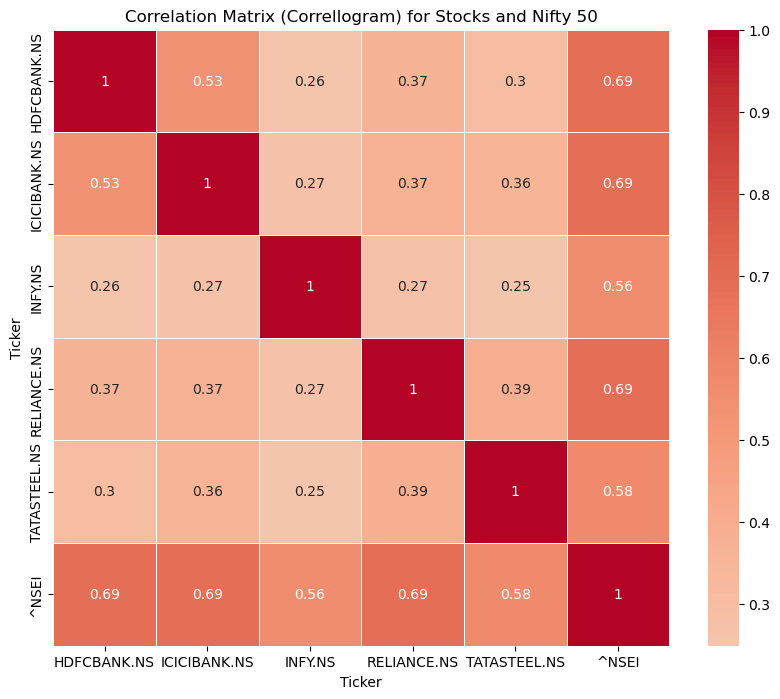

In [3]:
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1. Define stock tickers (include Nifty 50 as ^NSEI)
tickers = ['RELIANCE.NS', 'TATASTEEL.NS', 'INFY.NS', 'HDFCBANK.NS', 'ICICIBANK.NS']  # Replace with your 5 tickers
nifty_ticker = '^NSEI'

# 2. Calculate start and end dates for last 5 years
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# 3. Download stock and Nifty 50 data
data = yf.download(tickers + [nifty_ticker], start=start_date, end=end_date)['Close']  # Use 'Close' instead of 'Adj Close'

# 4. Calculate daily returns
returns_df = data.pct_change().dropna()

# 5. Create correlation matrix
corr_matrix = returns_df.corr()

# 6. Visualize correlation matrix as a heatmap (correllogram)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=.5)
plt.title('Correlation Matrix (Correllogram) for Stocks and Nifty 50')
plt.show()

In [5]:
# Descriptive statistics, formatted to 2 decimals and transposed
desc_stats = returns_df.describe().round(2).T
print(desc_stats)

               count  mean   std   min   25%  50%   75%   max
Ticker                                                       
HDFCBANK.NS   1236.0   0.0  0.01 -0.08 -0.01  0.0  0.01  0.10
ICICIBANK.NS  1236.0   0.0  0.01 -0.08 -0.01  0.0  0.01  0.12
INFY.NS       1236.0   0.0  0.02 -0.09 -0.01  0.0  0.01  0.08
RELIANCE.NS   1236.0   0.0  0.01 -0.07 -0.01  0.0  0.01  0.07
TATASTEEL.NS  1236.0   0.0  0.02 -0.13 -0.01  0.0  0.01  0.08
^NSEI         1236.0   0.0  0.01 -0.06 -0.00  0.0  0.01  0.05


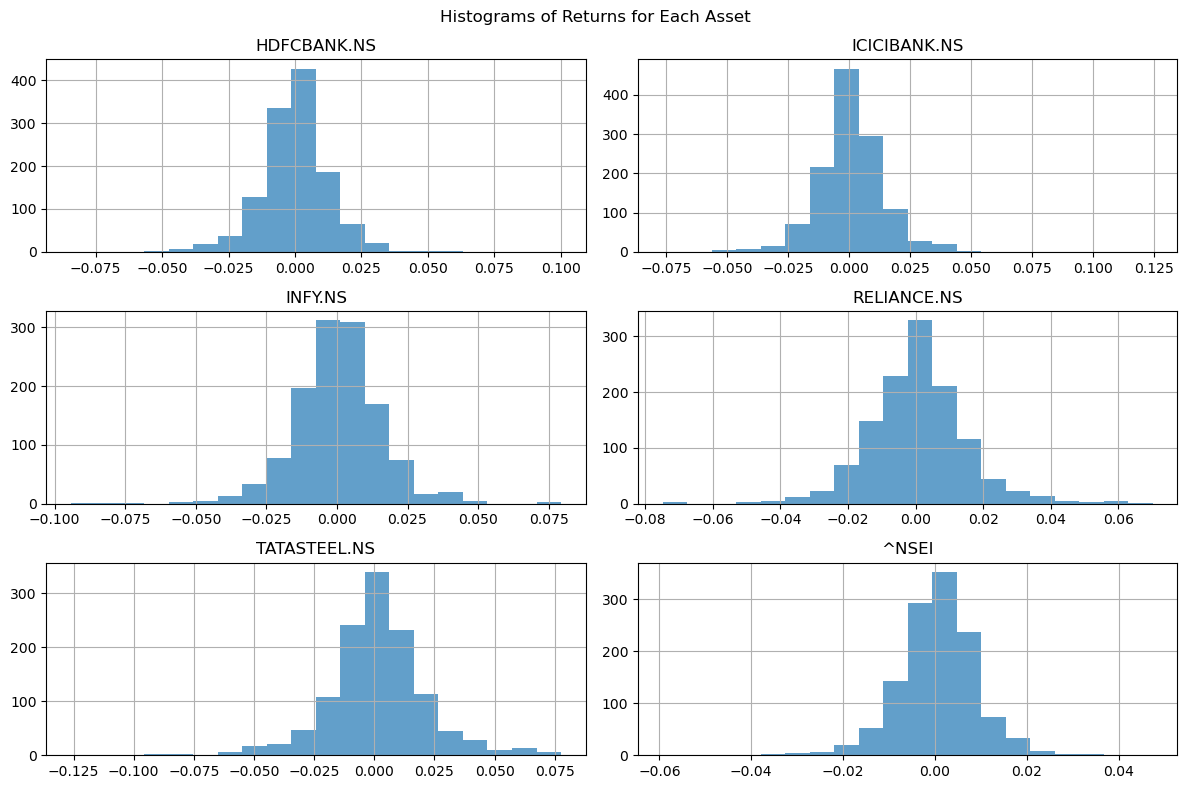

In [7]:
import matplotlib.pyplot as plt

# Plot histograms for each asset's returns
returns_df.hist(bins=20, figsize=(12, 8), alpha=0.7)
plt.suptitle('Histograms of Returns for Each Asset')
plt.tight_layout()
plt.show()

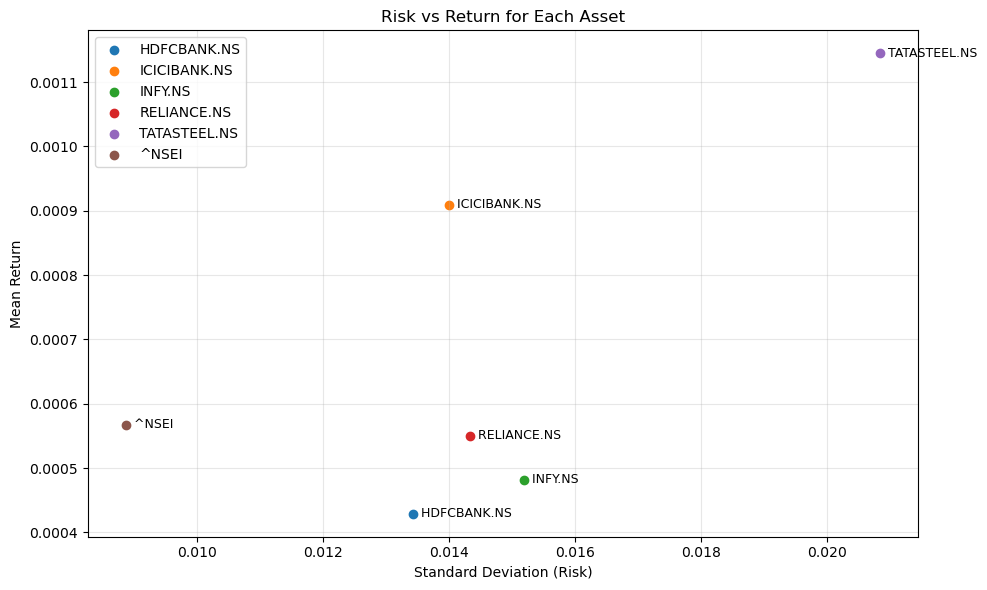

In [12]:
import matplotlib.pyplot as plt

# Calculate mean return and standard deviation for each asset
mean_returns = returns_df.mean()
std_returns = returns_df.std()

# Create scatter plot
plt.figure(figsize=(10, 6))
for asset in returns_df.columns:
    plt.scatter(std_returns[asset], mean_returns[asset], label=asset)
    # Add label text next to the point
    plt.text(std_returns[asset], mean_returns[asset], f'  {asset}', 
             fontsize=9, verticalalignment='center')

plt.xlabel('Standard Deviation (Risk)')
plt.ylabel('Mean Return')
plt.title('Risk vs Return for Each Asset')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



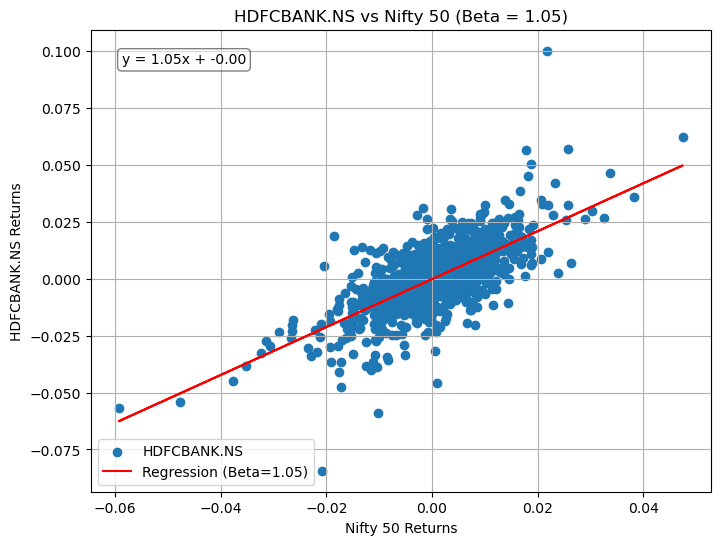

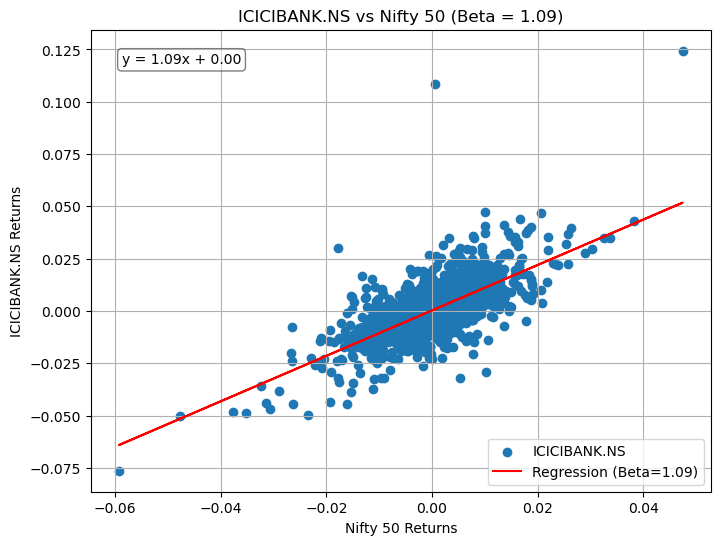

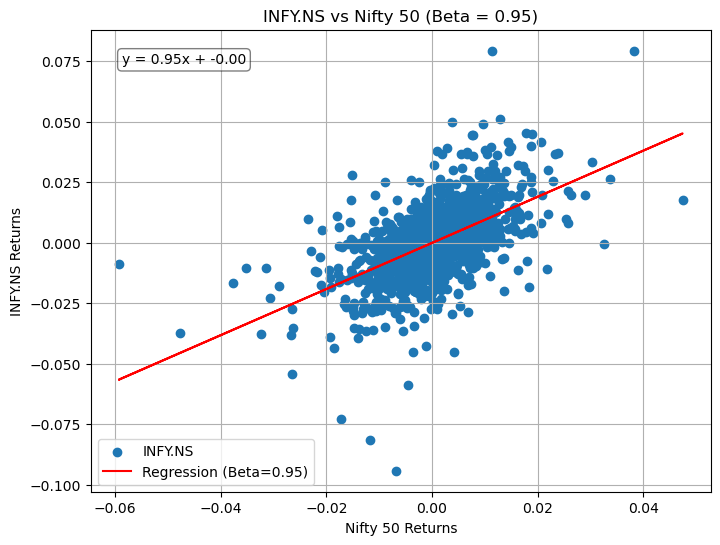

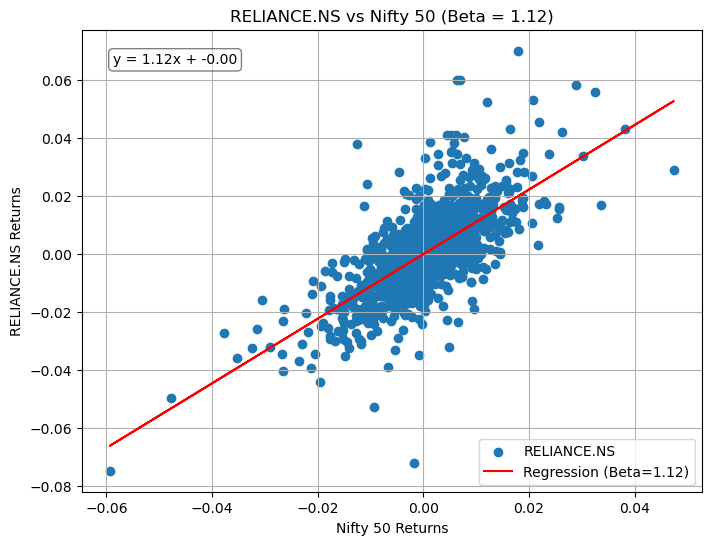

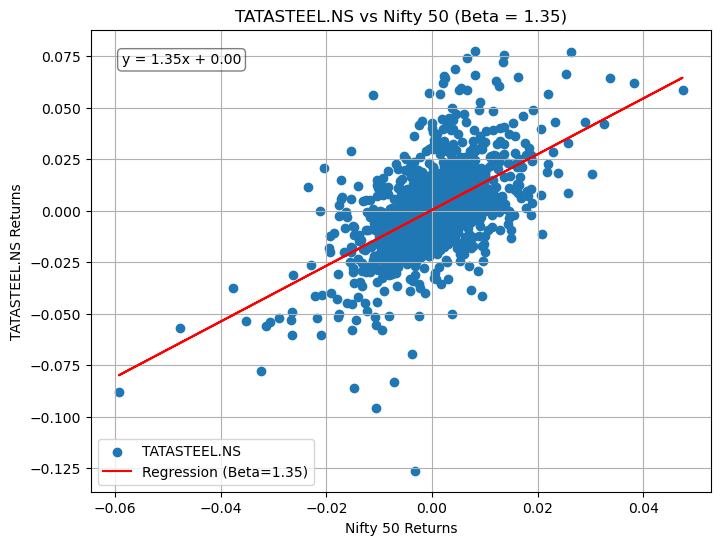

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Assume 'Nifty 50' is the column name for Nifty returns in returns_df
nifty_col = '^NSEI'  # Replace with your actual Nifty column name
market_returns = returns_df[nifty_col]

# Loop through each asset except Nifty
for asset in returns_df.columns:
    if asset == nifty_col:
        continue  # Skip Nifty

    asset_returns = returns_df[asset]
    
    # Calculate regression (Beta = slope)
    slope, intercept, r_value, p_value, std_err = stats.linregress(market_returns, asset_returns)
    beta = slope

    # Create scatter plot
    plt.figure(figsize=(8, 6))
    plt.scatter(market_returns, asset_returns, label=asset)
    
    # Plot regression line
    line = slope * market_returns + intercept
    plt.plot(market_returns, line, color='red', label=f'Regression (Beta={beta:.2f})')
    
    # Add regression equation to plot
    equation = f'y = {slope:.2f}x + {intercept:.2f}'
    plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.xlabel('Nifty 50 Returns')
    plt.ylabel(f'{asset} Returns')
    plt.title(f'{asset} vs Nifty 50 (Beta = {beta:.2f})')
    plt.legend()
    plt.grid(True)
    plt.show()